In [2]:
from __future__ import annotations
#importing required libraries
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import sklearn 
import onnx

# checking versions
print('numpy')
!pip3 show numpy|grep -i ^Version:
print('pandas')
!pip3 show pandas|grep -i ^Version:
print('seaborn')
!pip3 show seaborn|grep -i ^Version:
print('matplotlib')
!pip3 show matplotlib|grep -i ^Version:
print("sklearn")
!pip3 show scikit-learn|grep -i ^Version:
print('Onnx')
!pip3 show onnx|grep -i ^Version:
# print("numpy:\t",np.__version__)
# print("pandas:\t",pd.__version__)
# !pip3 show seaborn|grep -i 
# !pip3 show matplotlib|grep -i
# !pip3 show sklearn|grep -i
# !pip3 show onnx|grep -i


numpy
Version: 2.4.4
pandas
Version: 3.0.5
seaborn
Version: 0.13.2
matplotlib
Version: 3.11.1
sklearn
Version: 1.9.0
Onnx
Version: 1.22.0


In [3]:
##importing current dataset 
#importing required libraries
import pandas as pd
import numpy as np

import os 
import sys

path='/home/dreams/Projects/DataScienceProjects/MachineLearningProject/IntroductionMachineLearning/dataset/spotifyTrackingDataset'
folder='spotify-tracks-dataset-detailed.csv'
fullPath=os.path.join(path,folder)
# print(fullPath)
# print(os.path.exists(fullPath))
if os.path.exists(fullPath):
    dataset=pd.read_csv(fullPath,on_bad_lines='skip')
    
else:
    raise Exception("Couldn't find path")


In [4]:
# data wrangling current dataset
# dataset.head()
dataset.drop(columns=['track_id','time_signature'],inplace=True)
# dataset.head()
dataset.info()
# dataset.describe()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   artists           113999 non-null  str    
 1   album_name        113999 non-null  str    
 2   track_name        113999 non-null  str    
 3   popularity        114000 non-null  int64  
 4   duration_ms       114000 non-null  int64  
 5   explicit          114000 non-null  bool   
 6   danceability      114000 non-null  float64
 7   energy            114000 non-null  float64
 8   key               114000 non-null  int64  
 9   loudness          114000 non-null  float64
 10  mode              114000 non-null  int64  
 11  speechiness       114000 non-null  float64
 12  acousticness      114000 non-null  float64
 13  instrumentalness  114000 non-null  float64
 14  liveness          114000 non-null  float64
 15  valence           114000 non-null  float64
 16  tempo             114000 non-nu

In [5]:
#output count of observations 
dataset.shape[0]

114000

In [6]:
#converting current np.int64 columns to np.float64
intColumns=dataset.select_dtypes(np.int64).columns

dataset[intColumns]=dataset[intColumns].astype(np.float64)
# dataset[intColumns]

In [7]:
#converting duration_ms to seconds
dataset['duration_s']=dataset['duration_ms']/60
dataset.drop(columns=['duration_ms'],inplace=True)

In [8]:
#removing Nan from dataset
dataset.dropna(inplace=True,axis=0)

In [9]:
dataset.info()

<class 'pandas.DataFrame'>
Index: 113999 entries, 0 to 113999
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   artists           113999 non-null  str    
 1   album_name        113999 non-null  str    
 2   track_name        113999 non-null  str    
 3   popularity        113999 non-null  float64
 4   explicit          113999 non-null  bool   
 5   danceability      113999 non-null  float64
 6   energy            113999 non-null  float64
 7   key               113999 non-null  float64
 8   loudness          113999 non-null  float64
 9   mode              113999 non-null  float64
 10  speechiness       113999 non-null  float64
 11  acousticness      113999 non-null  float64
 12  instrumentalness  113999 non-null  float64
 13  liveness          113999 non-null  float64
 14  valence           113999 non-null  float64
 15  tempo             113999 non-null  float64
 16  track_genre       113999 non-null  s

In [10]:
# label encoding for bool features
boolFeatures=dataset.select_dtypes(np.bool).columns

#importing required libraries 
from sklearn.preprocessing import LabelEncoder

encoder=LabelEncoder()
encodedVersion=encoder.fit_transform(dataset[boolFeatures])

dataset=dataset.assign(explicit=encodedVersion)

dataset

# converting seconds to minutes
#Robustscaling for encoded track name feature


/home/dreams/Projects/.venv/lib/python3.14/site-packages/sklearn/preprocessing/_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,artists,album_name,track_name,popularity,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,track_genre,duration_s
0,Gen Hoshino,Comedy,Comedy,73.0,0,0.676,0.4610,1.0,-6.746,0.0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,acoustic,3844.433333
1,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55.0,0,0.420,0.1660,1.0,-17.235,1.0,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,acoustic,2493.500000
2,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57.0,0,0.438,0.3590,0.0,-9.734,1.0,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,acoustic,3513.766667
3,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71.0,0,0.266,0.0596,0.0,-18.515,1.0,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,acoustic,3365.550000
4,Chord Overstreet,Hold On,Hold On,82.0,0,0.618,0.4430,2.0,-9.681,1.0,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,acoustic,3314.216667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21.0,0,0.172,0.2350,5.0,-16.393,1.0,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,world-music,6416.650000
113996,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22.0,0,0.174,0.1170,0.0,-18.318,0.0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,world-music,6416.666667
113997,Cesária Evora,Best Of,Miss Perfumado,22.0,0,0.629,0.3290,0.0,-10.895,0.0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,world-music,4524.433333
113998,Michael W. Smith,Change Your World,Friends,41.0,0,0.587,0.5060,7.0,-10.889,1.0,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,world-music,4731.550000


In [11]:
any(dataset.explicit) #returns True

True

/tmp/ipykernel_21265/3584907412.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes1.legend()


Text(0.5, 1.0, 'Popularity Line chart')

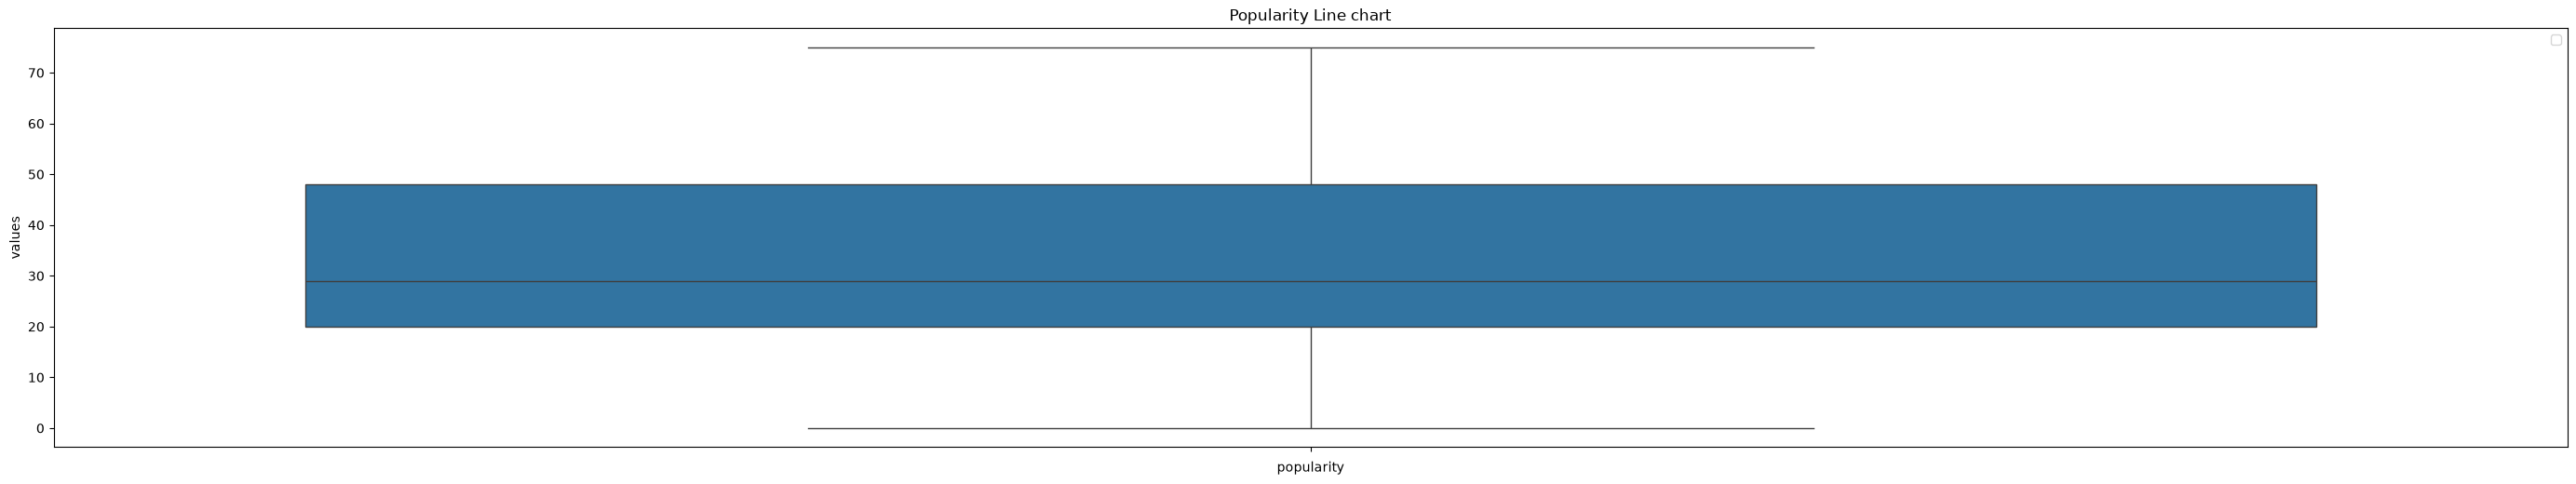

In [12]:
###Exploratory Data Analysis for current features
#popularity feature
#importing required libraries
import matplotlib.pyplot as plt
import seaborn as sns

cols=dataset['popularity'][10:2000]

# creating line plot for popularity feature
fig1=plt.figure(figsize=(30,5),dpi=100)
axes1=fig1.add_axes([0.1,0.1,0.9,0.9])
sns.boxplot(cols,ax=axes1)
axes1.set_xlabel('popularity')
axes1.set_ylabel('values')
axes1.legend()
axes1.set_title('Popularity Line chart')



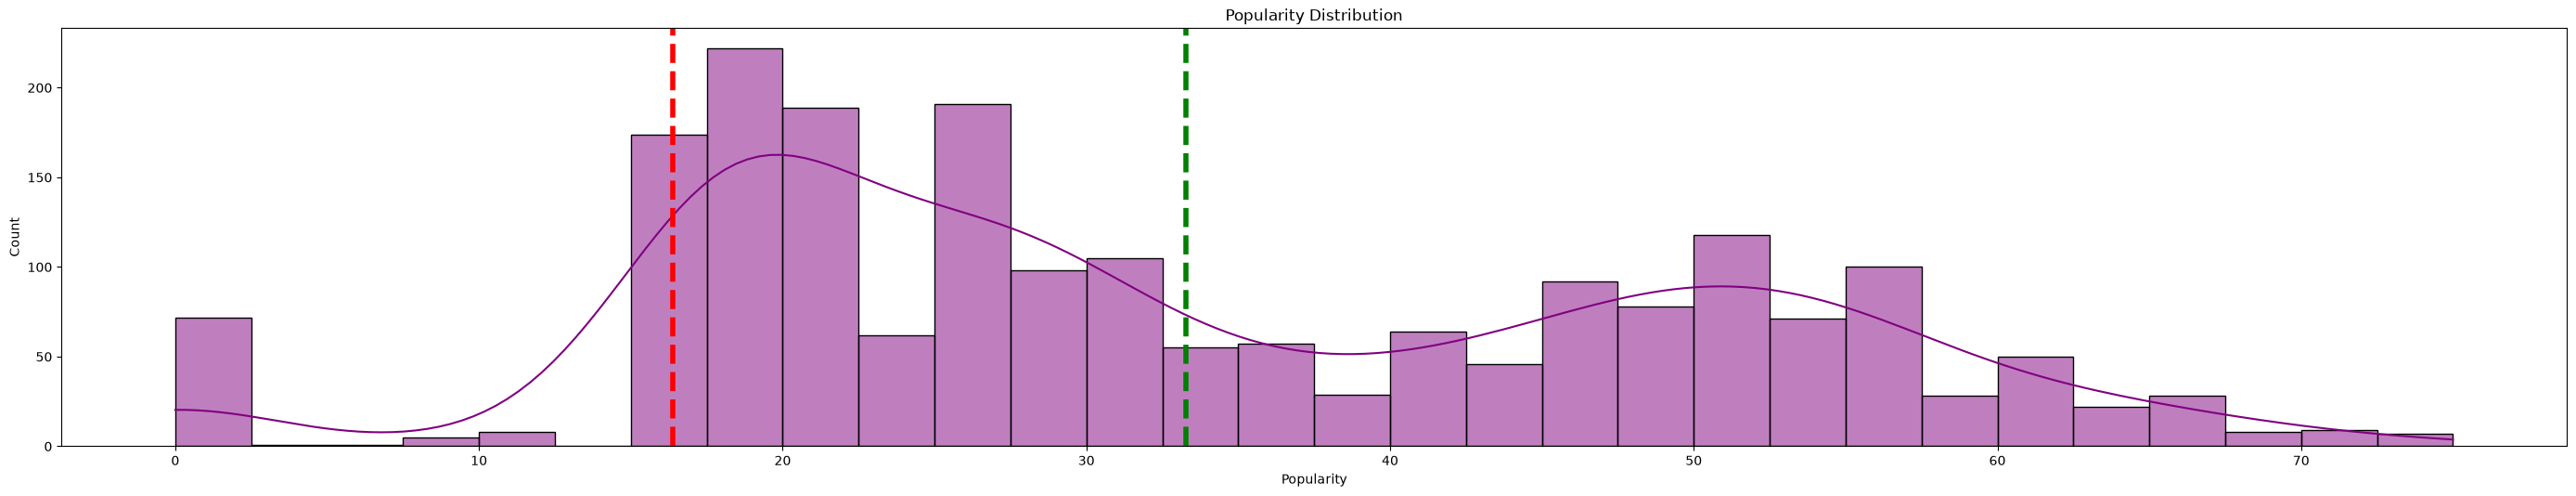

In [13]:
## creating histplot for popularity feature
#using seaborn for histplot

import matplotlib.pyplot as plt
%matplotlib inline

fig2=plt.figure(figsize=(30,5),dpi=100)
axes2=fig2.add_axes([0.1,0.1,0.9,0.9])


sns.histplot(cols,kde=True,bins=30,color='purple',ax=axes2)

axes2.set_title("Popularity Distribution")
axes2.set_xlabel("Popularity")
axes2.set_ylabel("Count")
plt.axvline(cols.std(),color='red',linewidth=4,linestyle='dashed')
plt.axvline(cols.mean(),color='green',linewidth=4,linestyle='dashed')

plt.show()



In [14]:
cols.describe()

count    1990.000000
mean       33.267337
std        16.389364
min         0.000000
25%        20.000000
50%        29.000000
75%        48.000000
max        75.000000
Name: popularity, dtype: float64

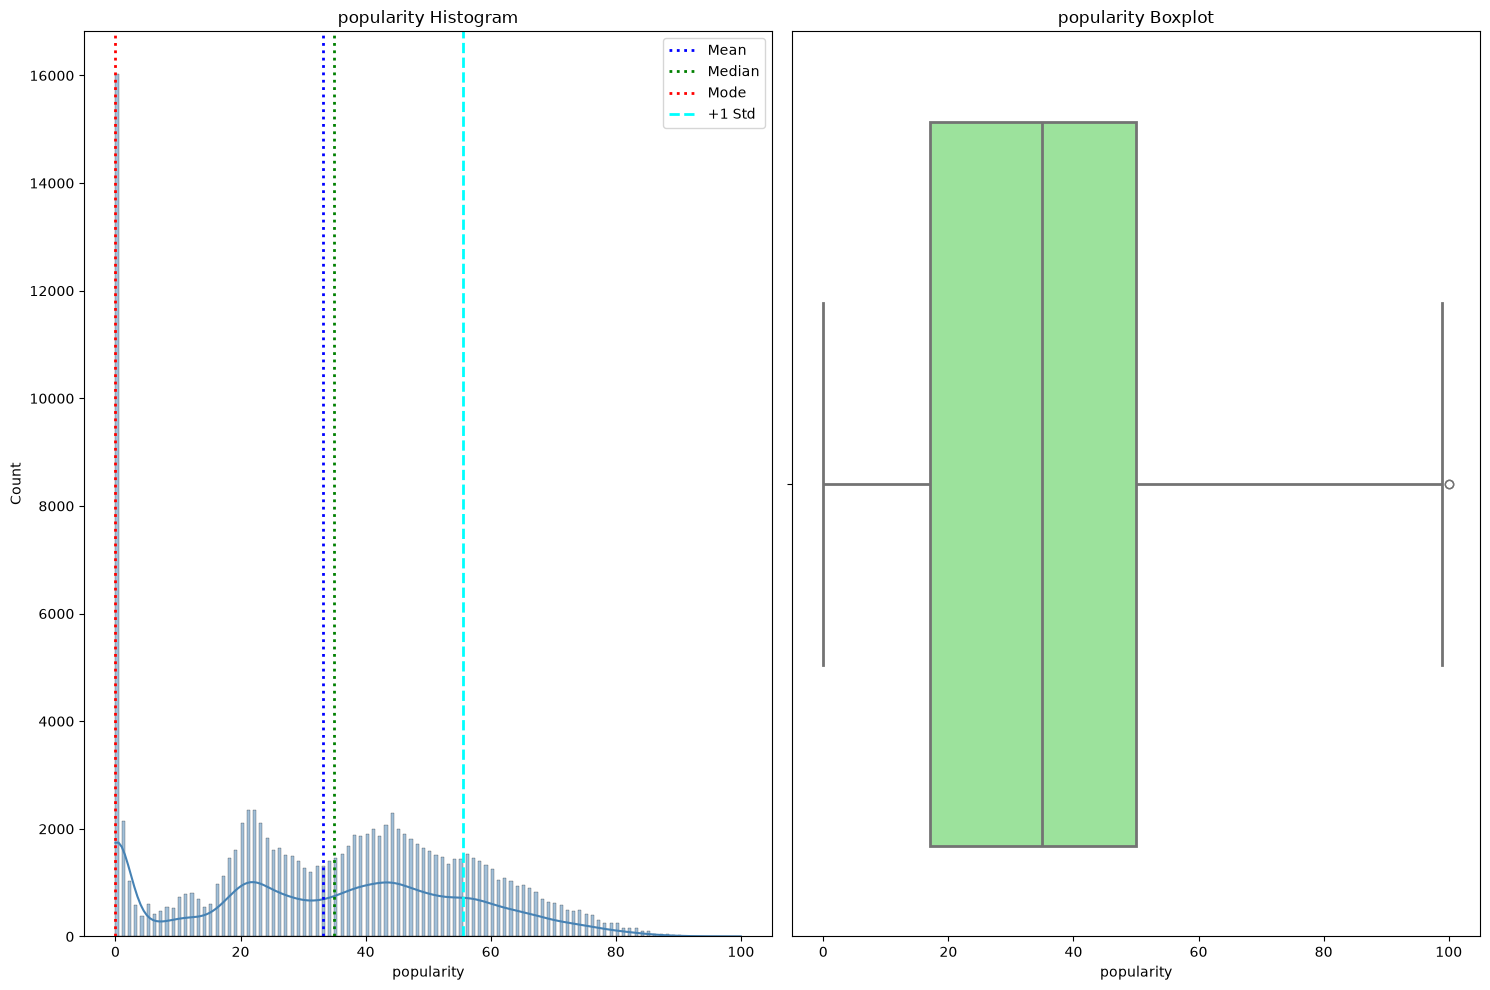

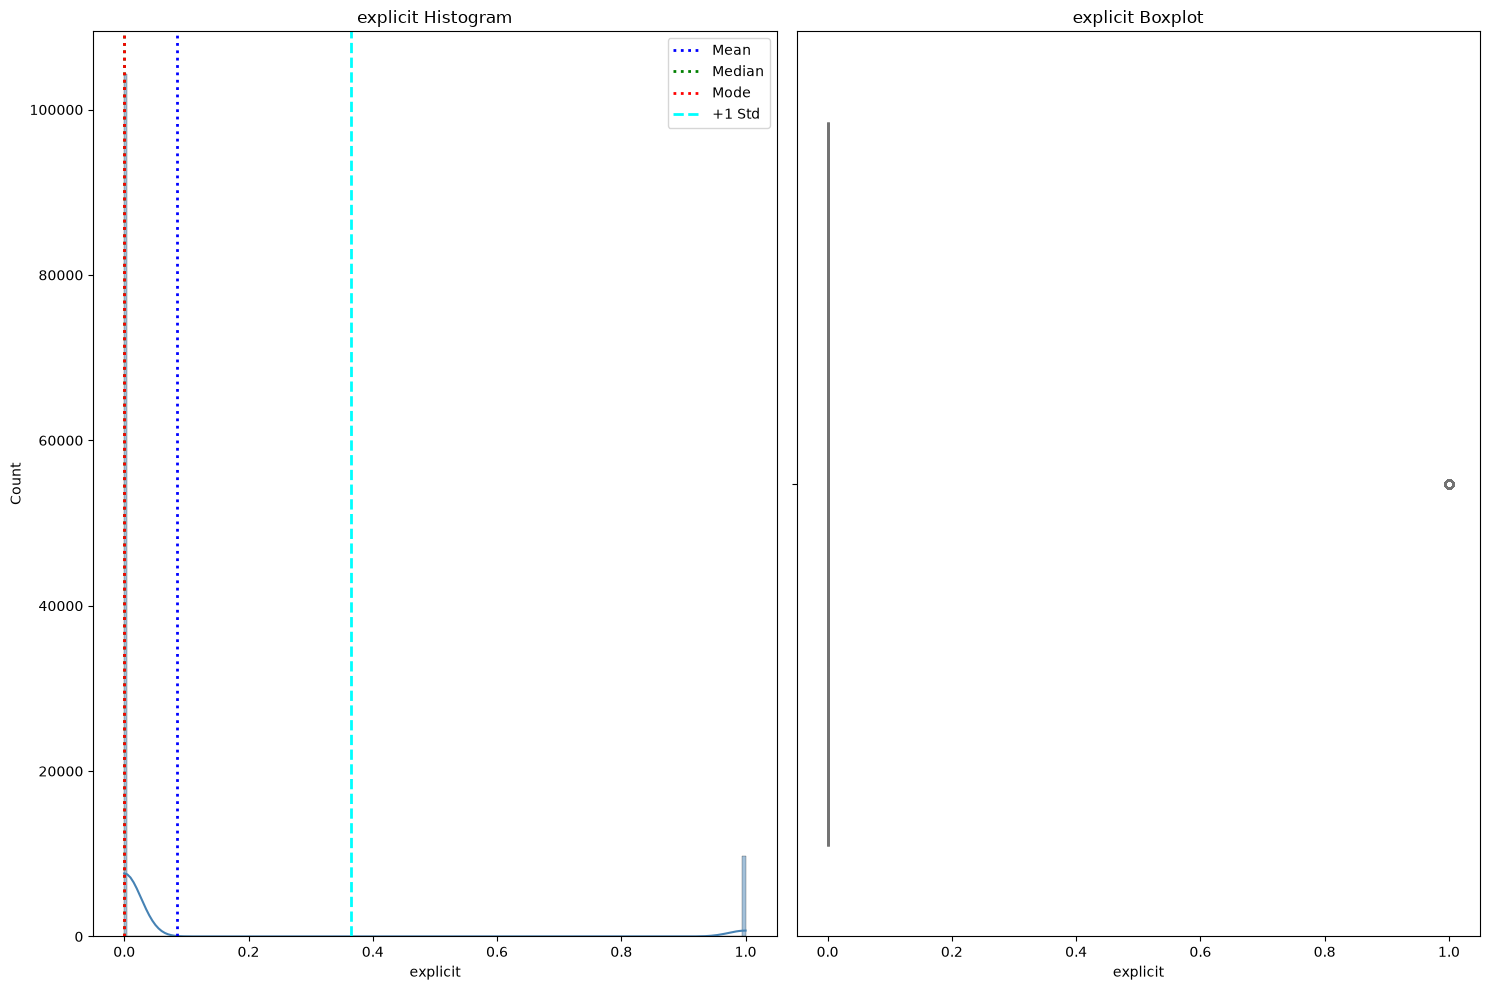

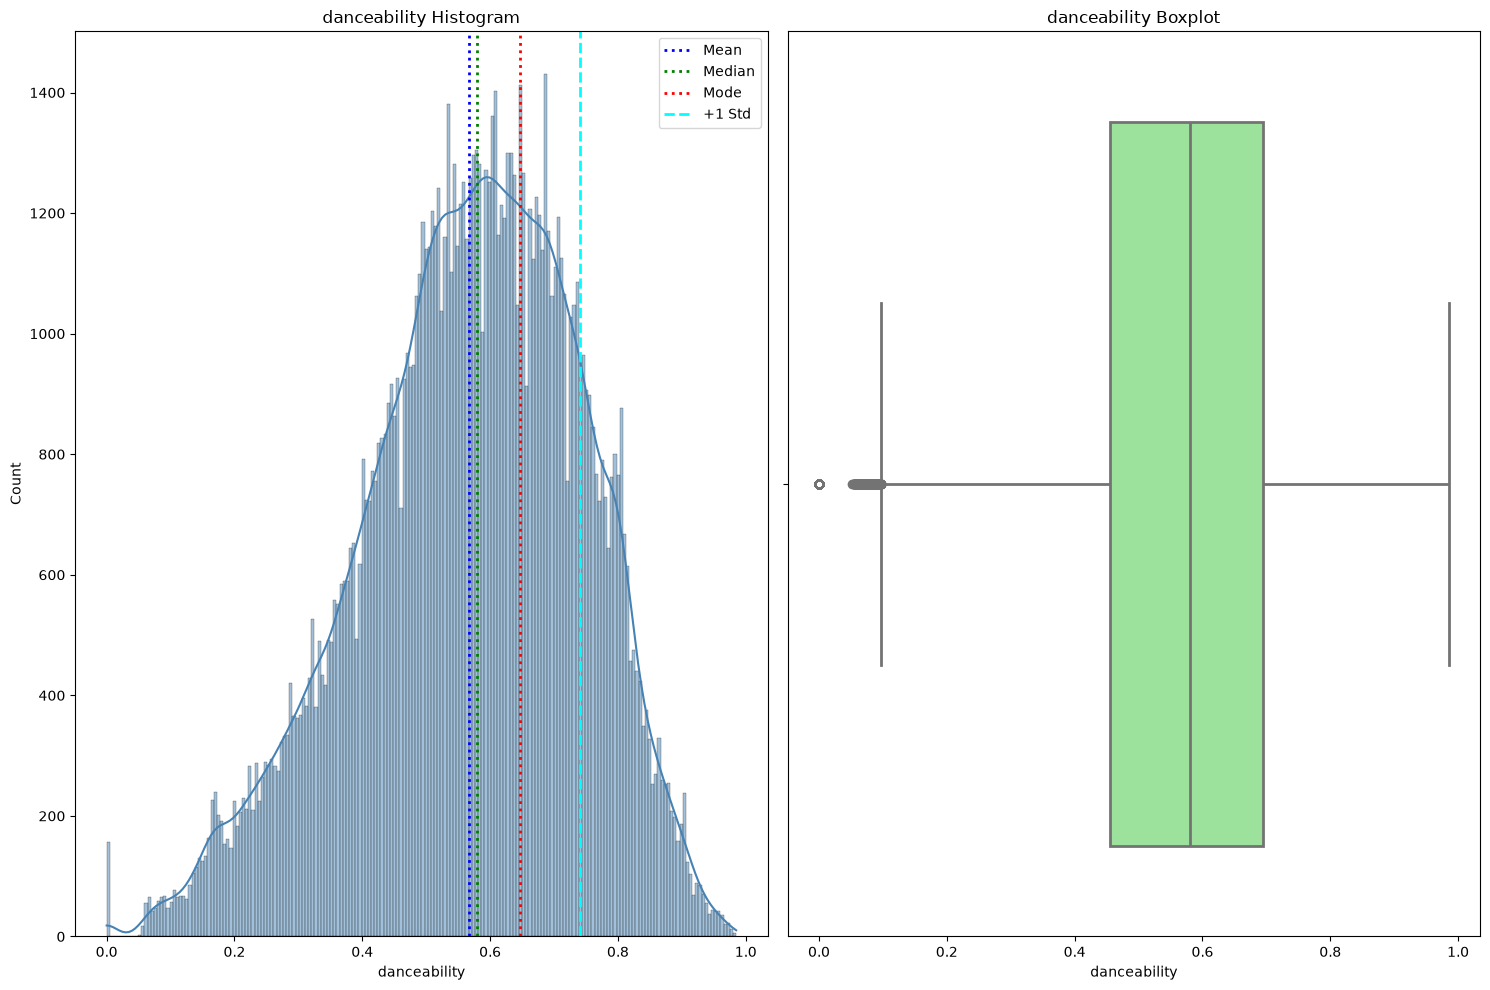

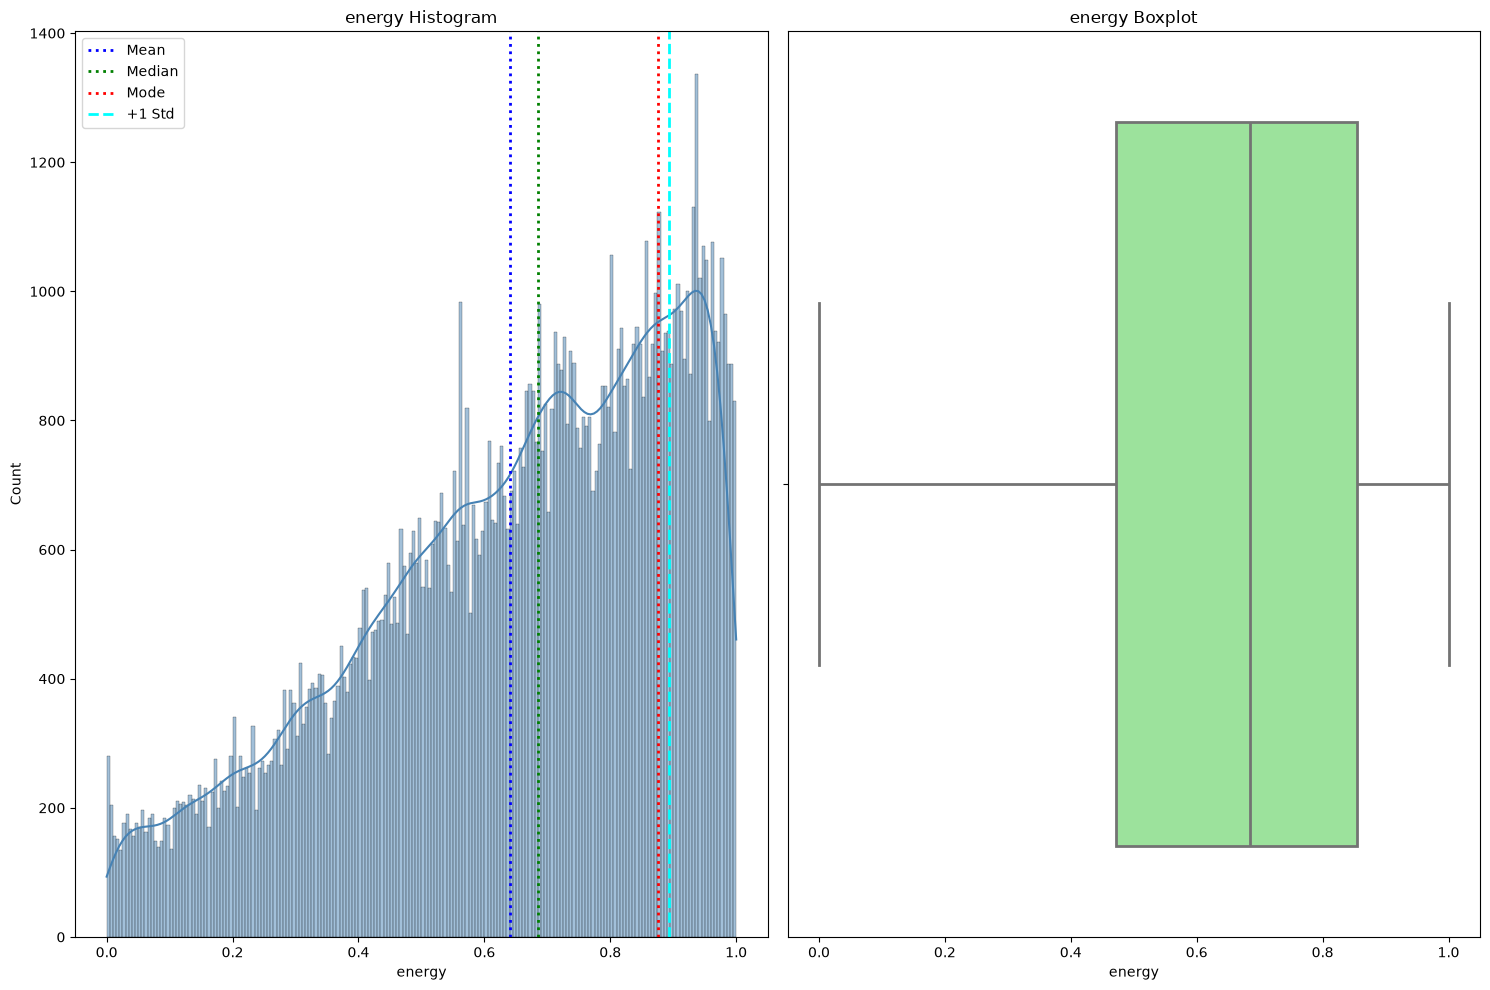

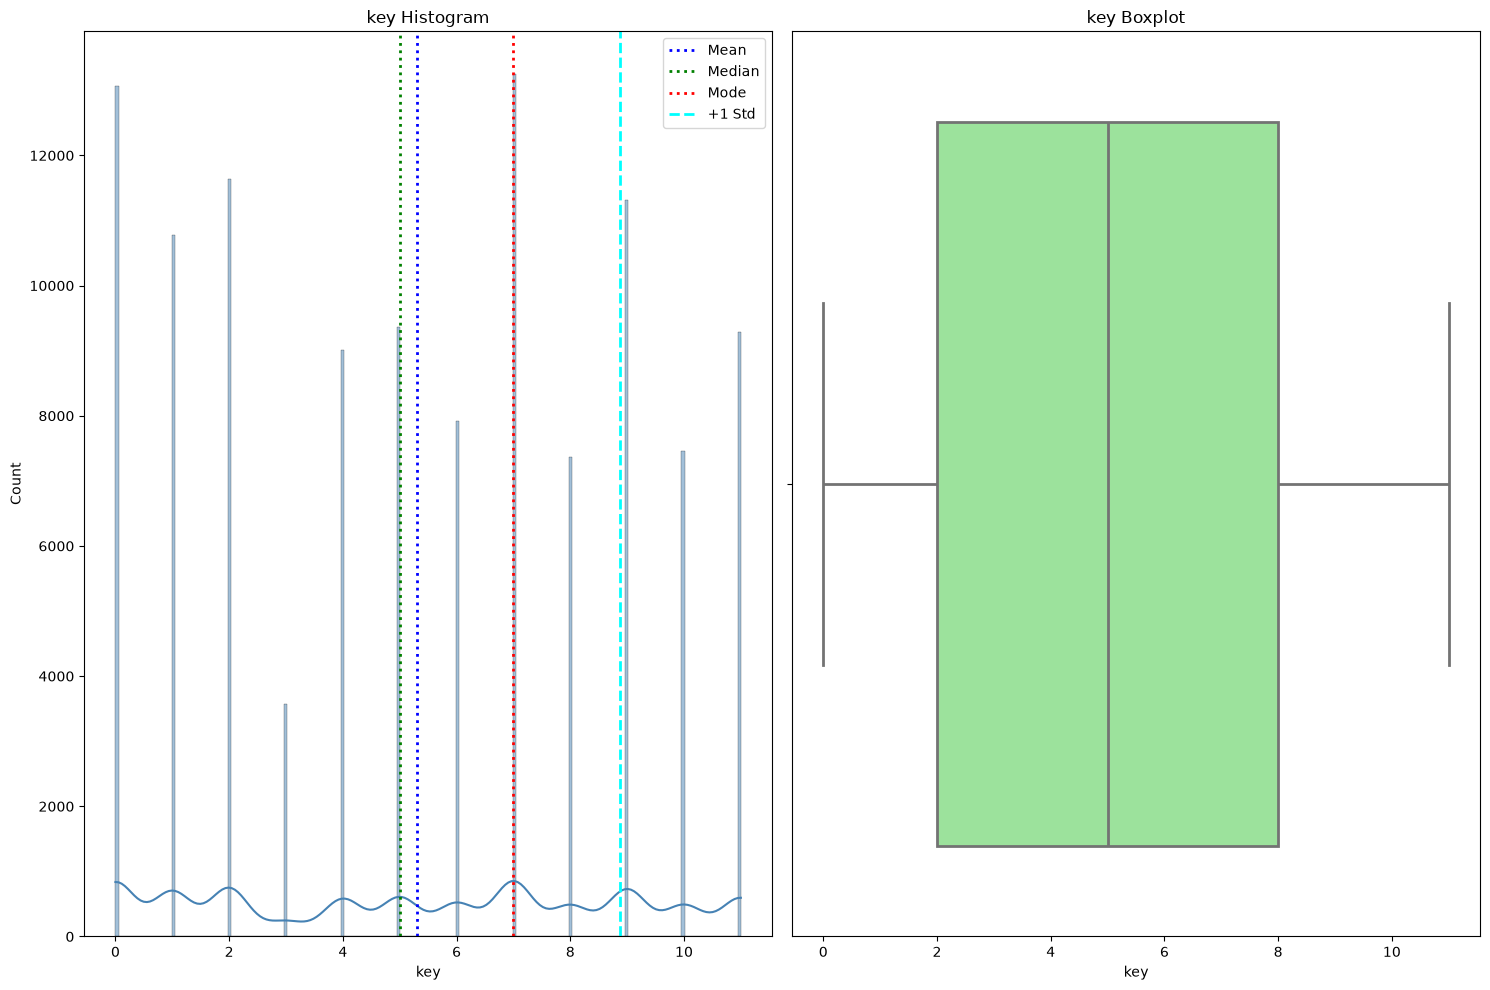

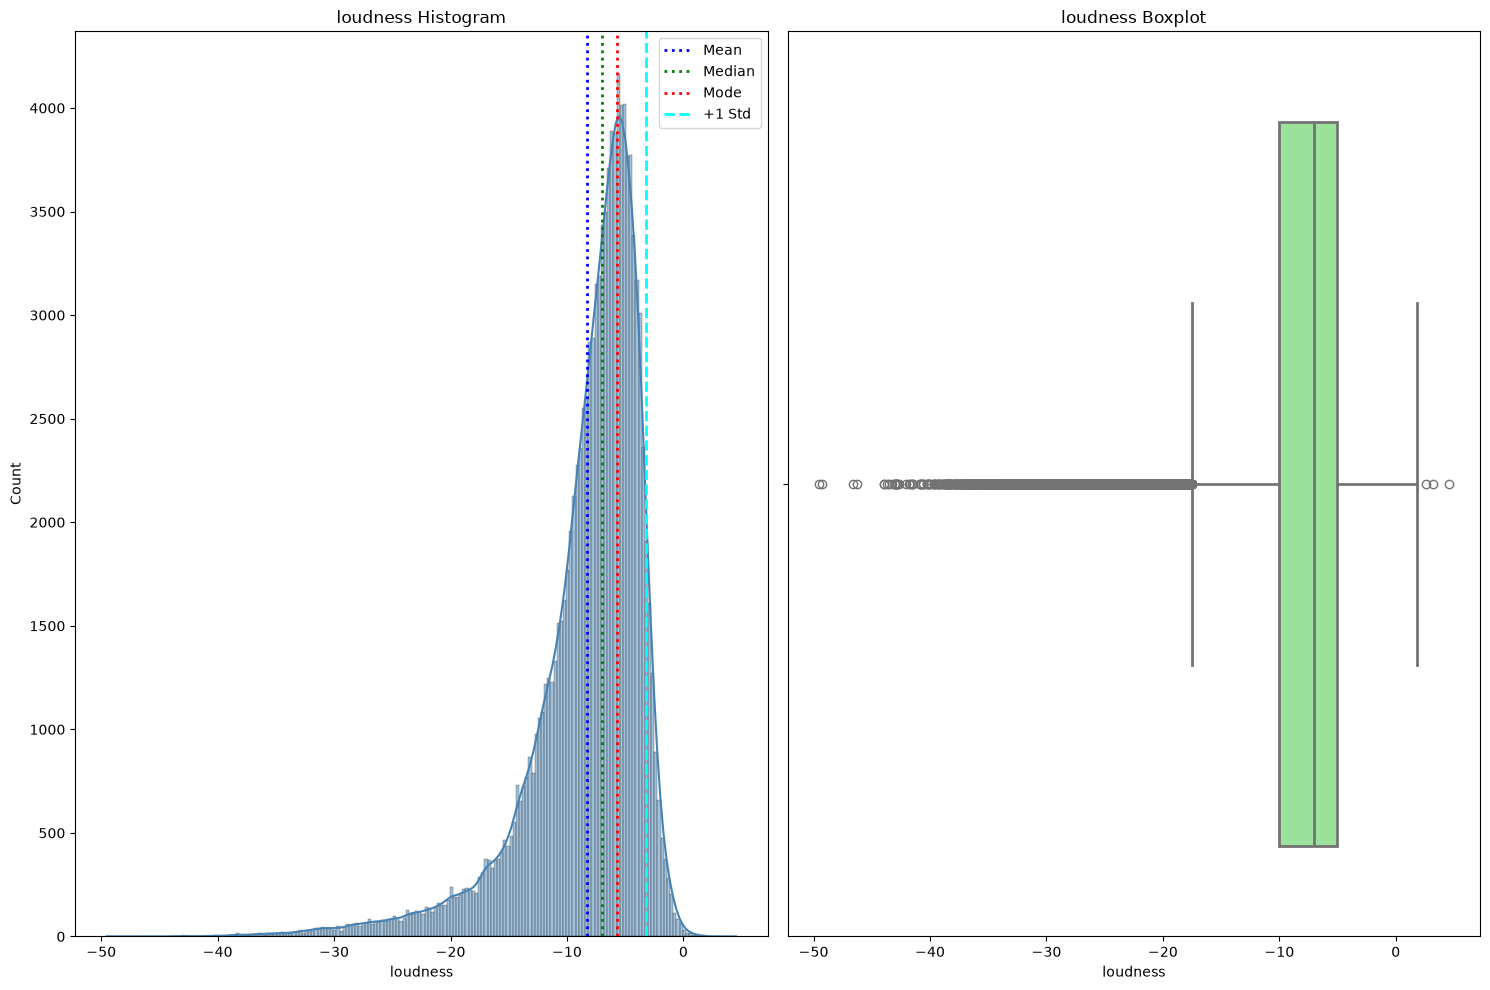

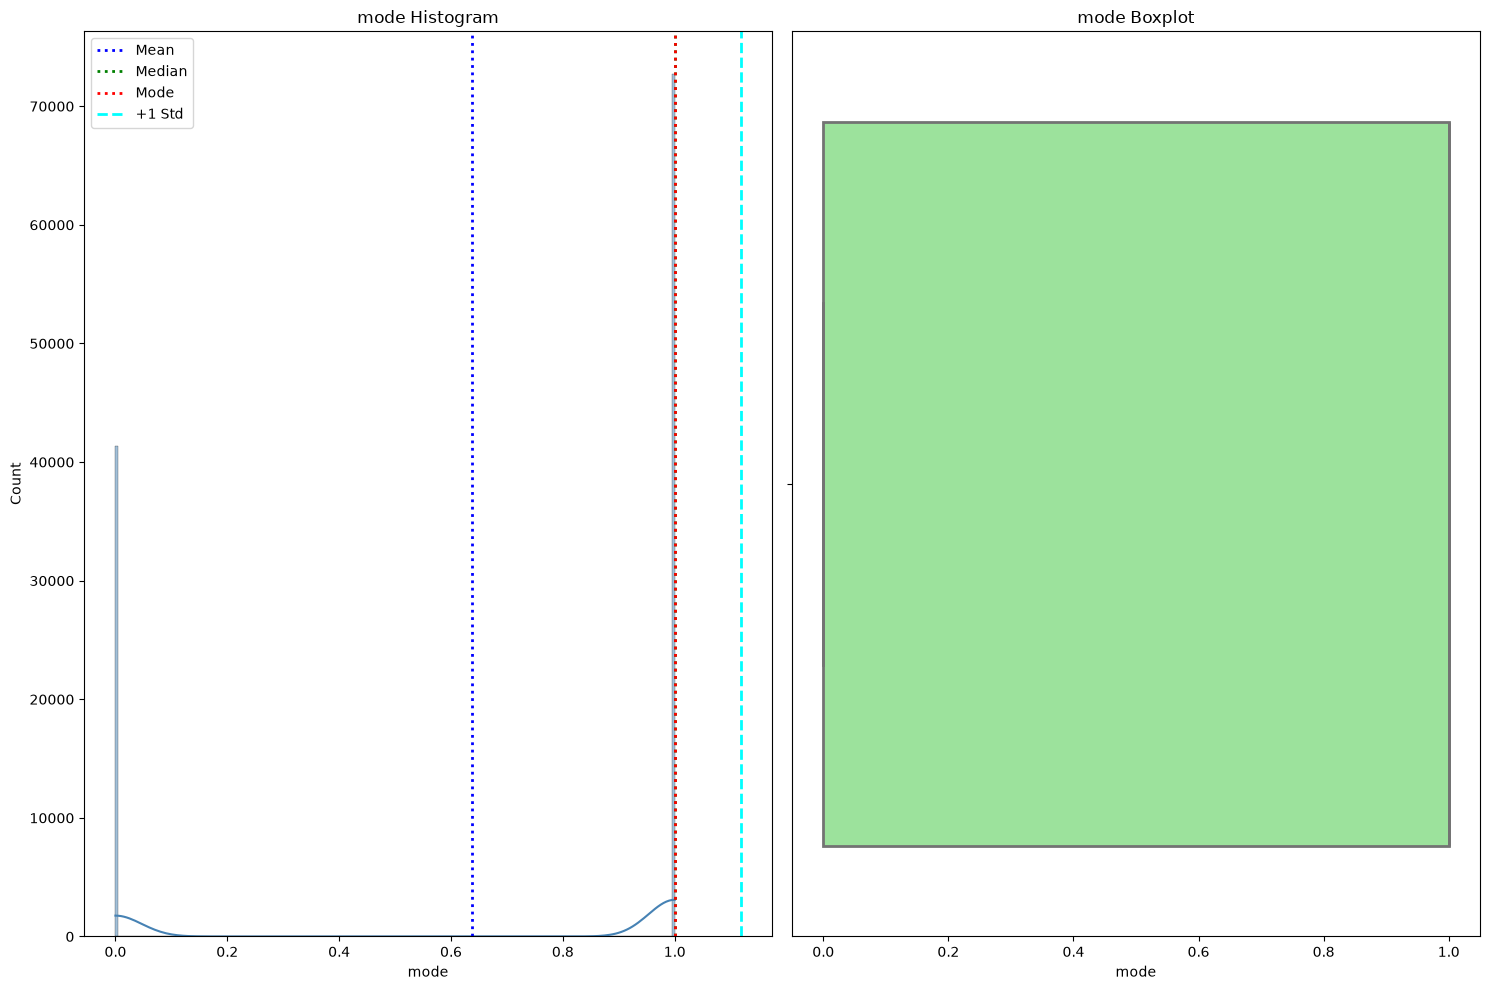

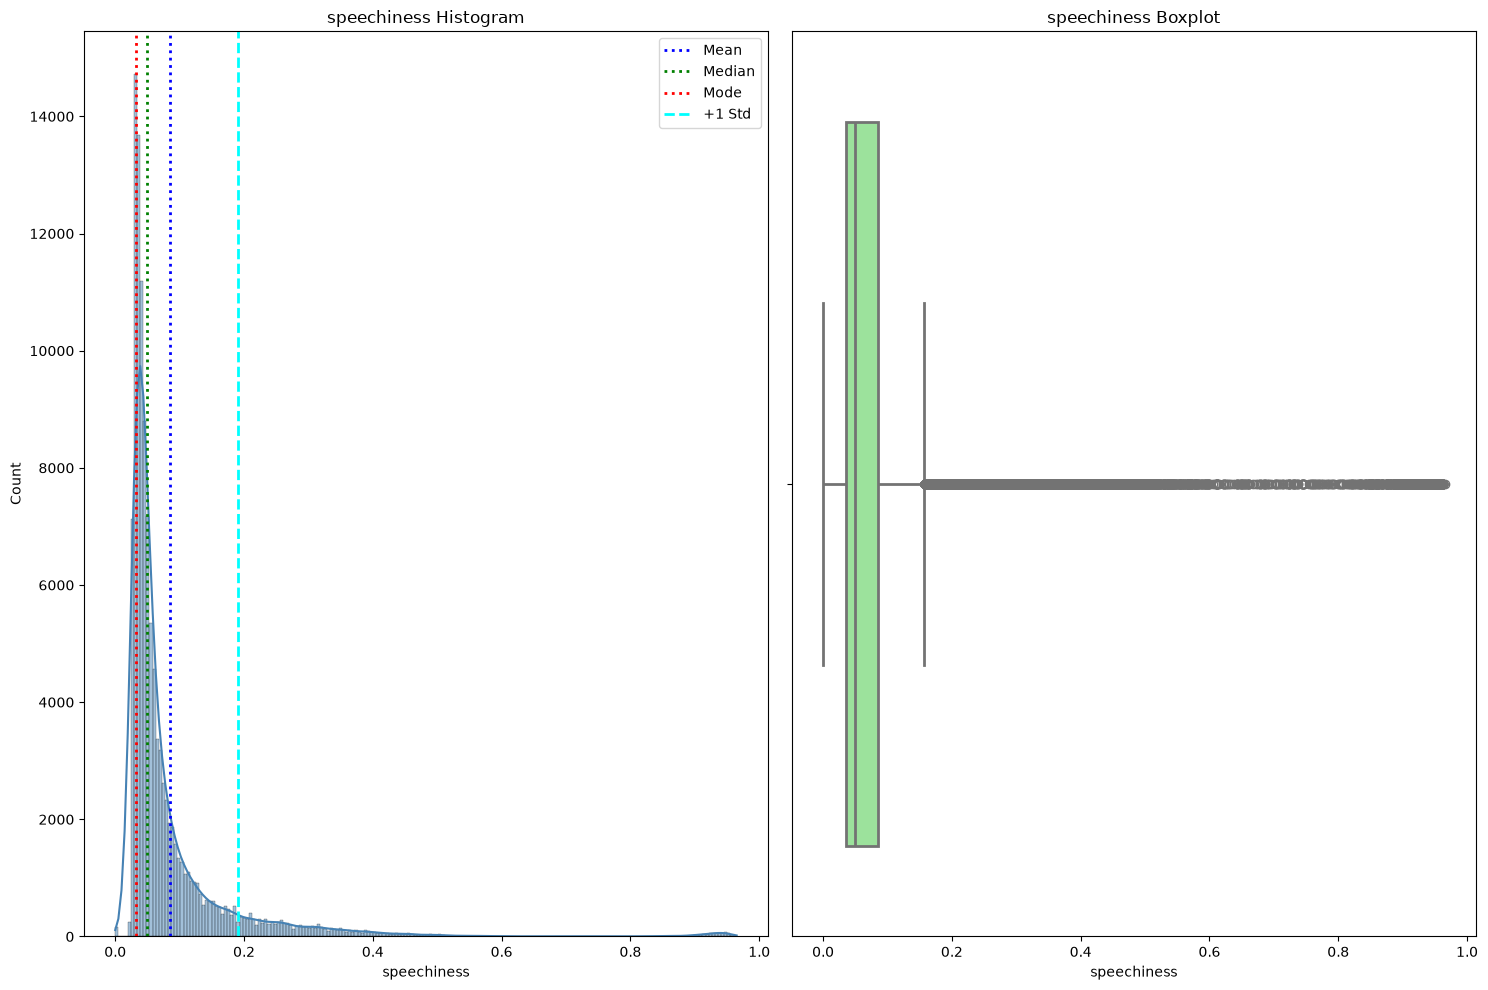

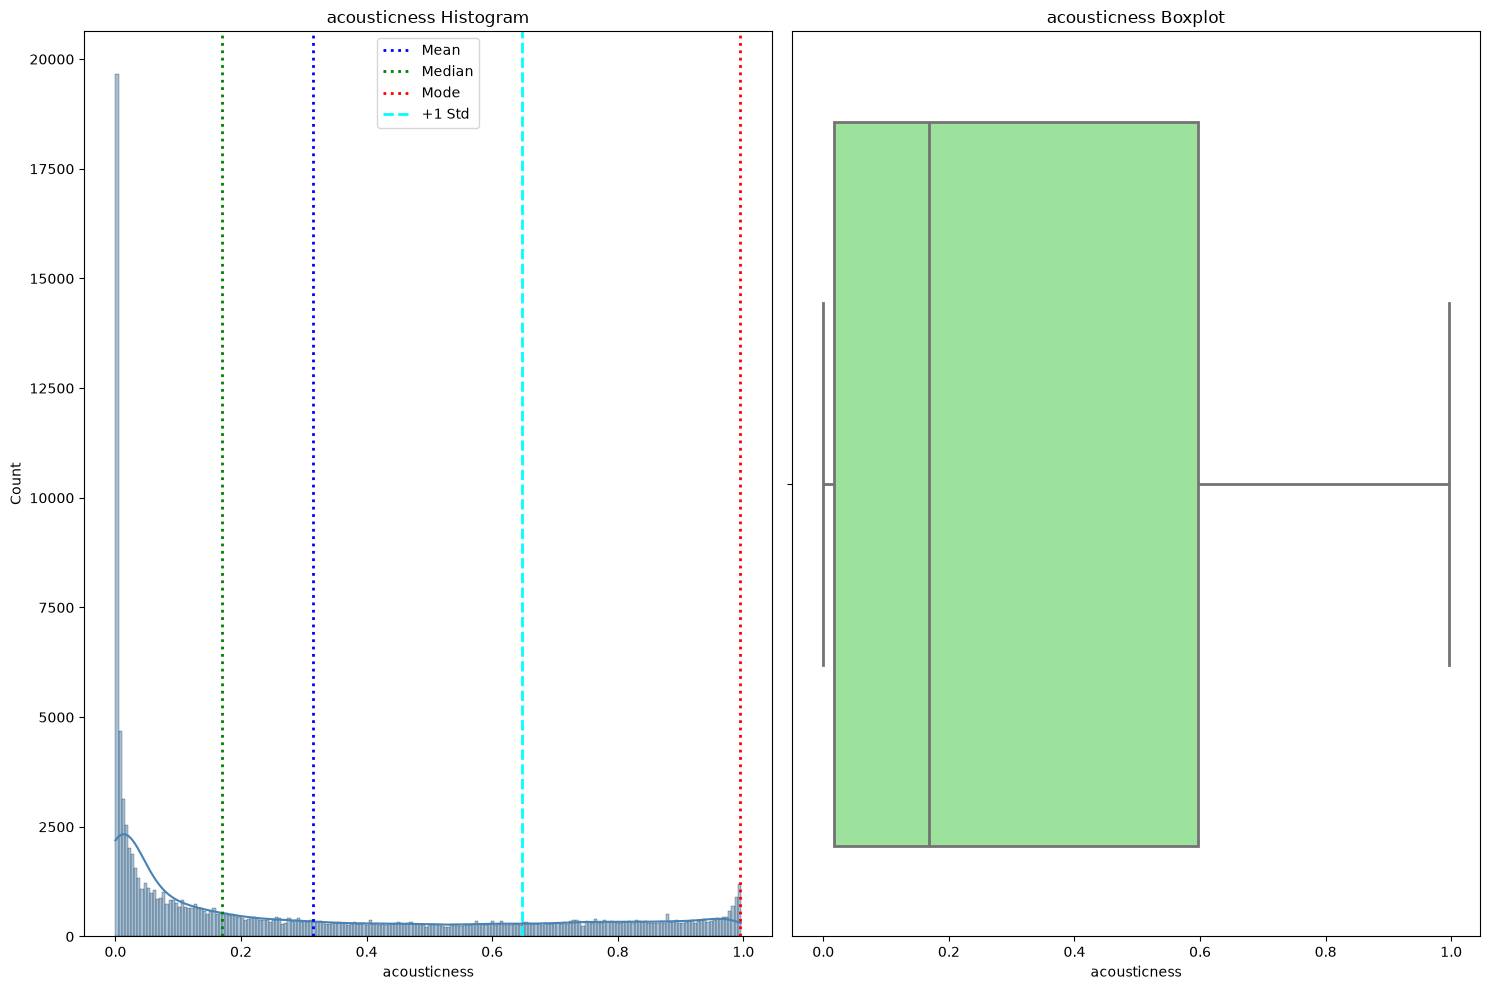

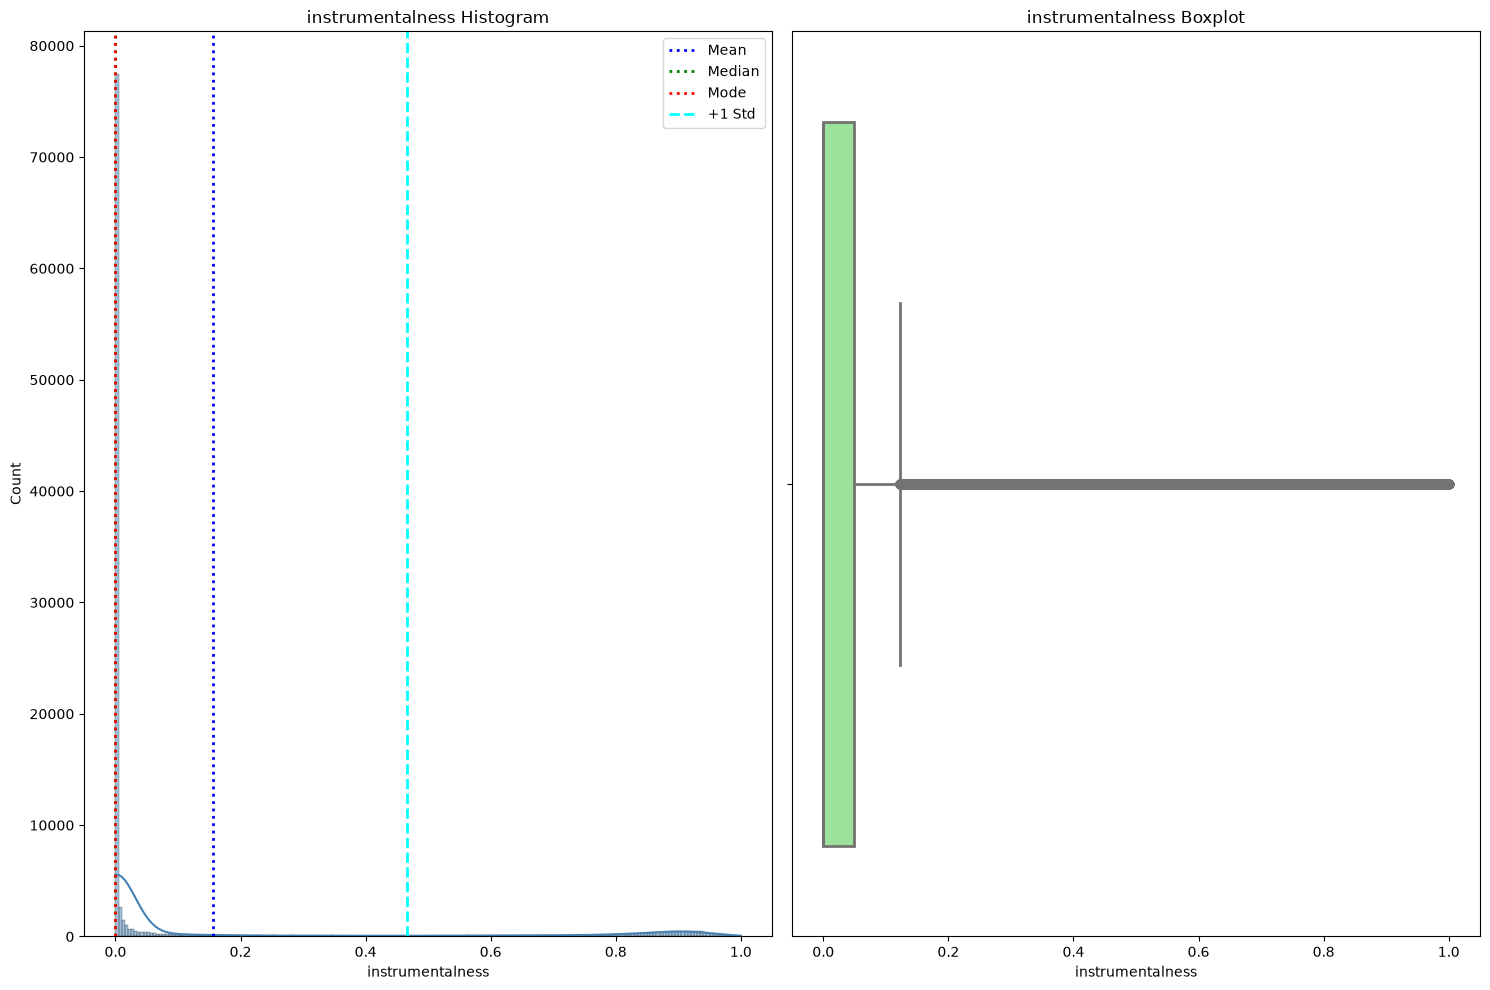

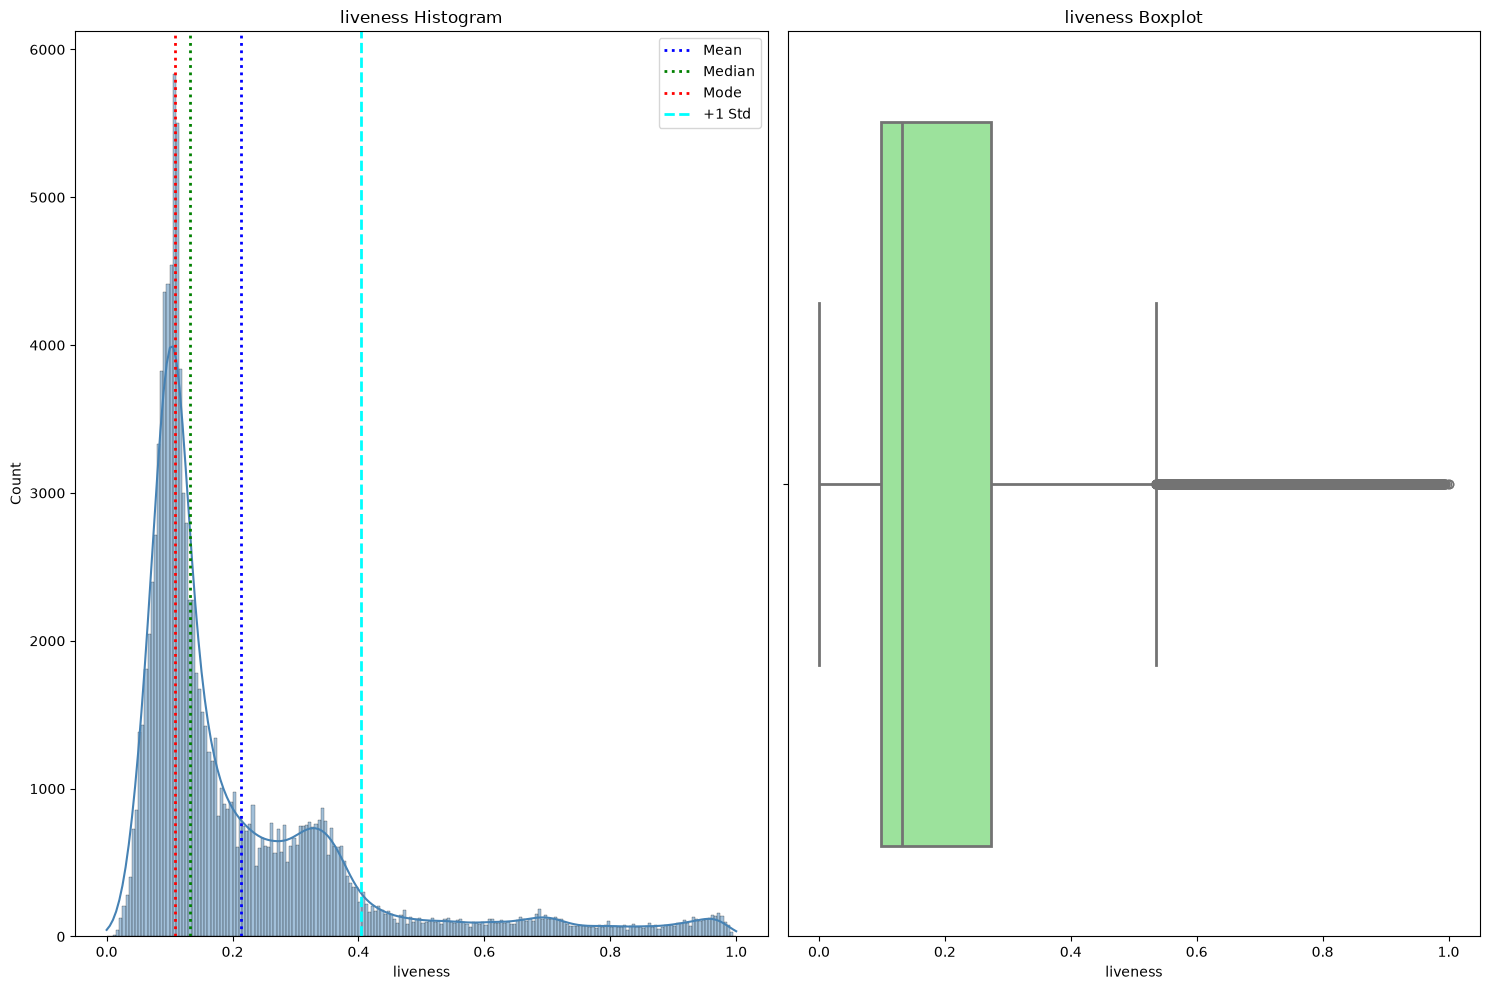

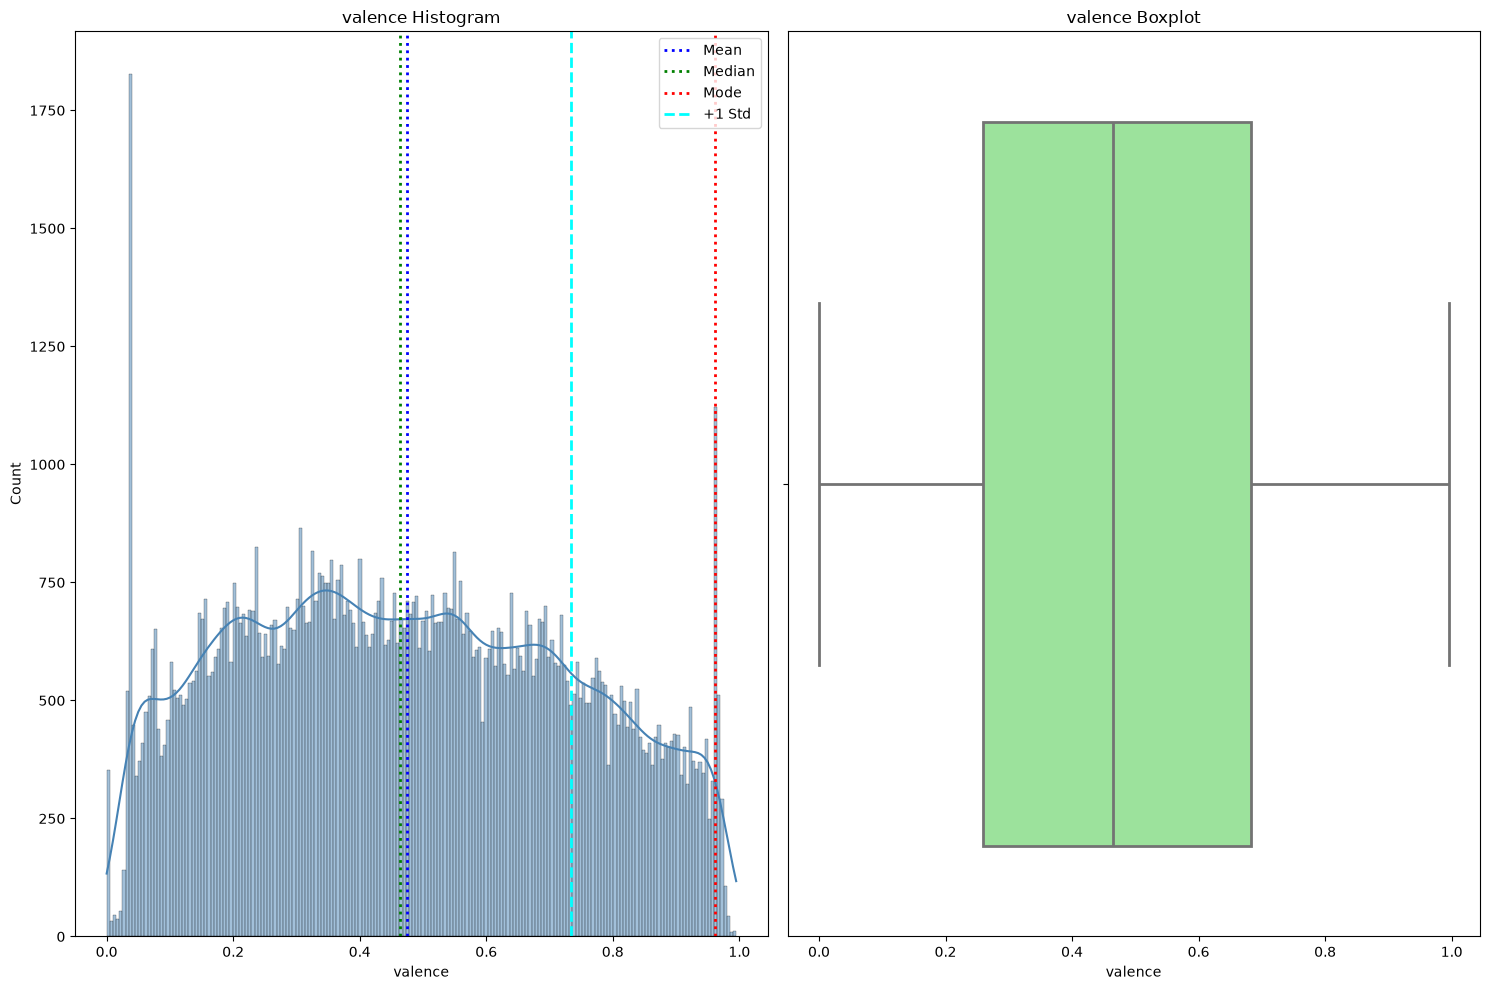

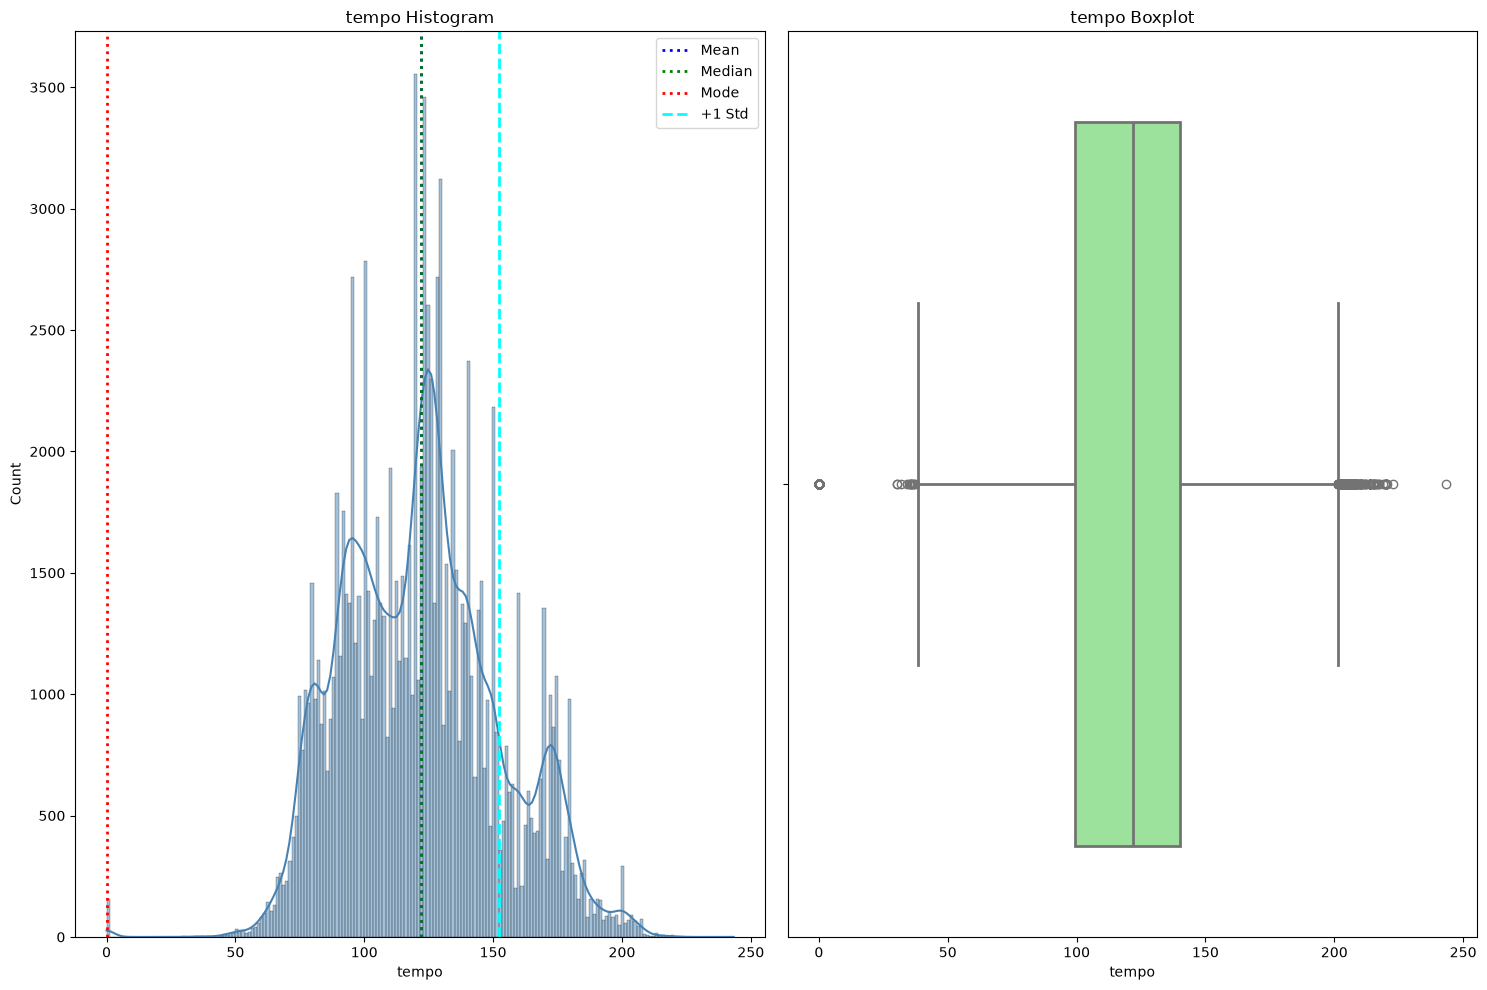

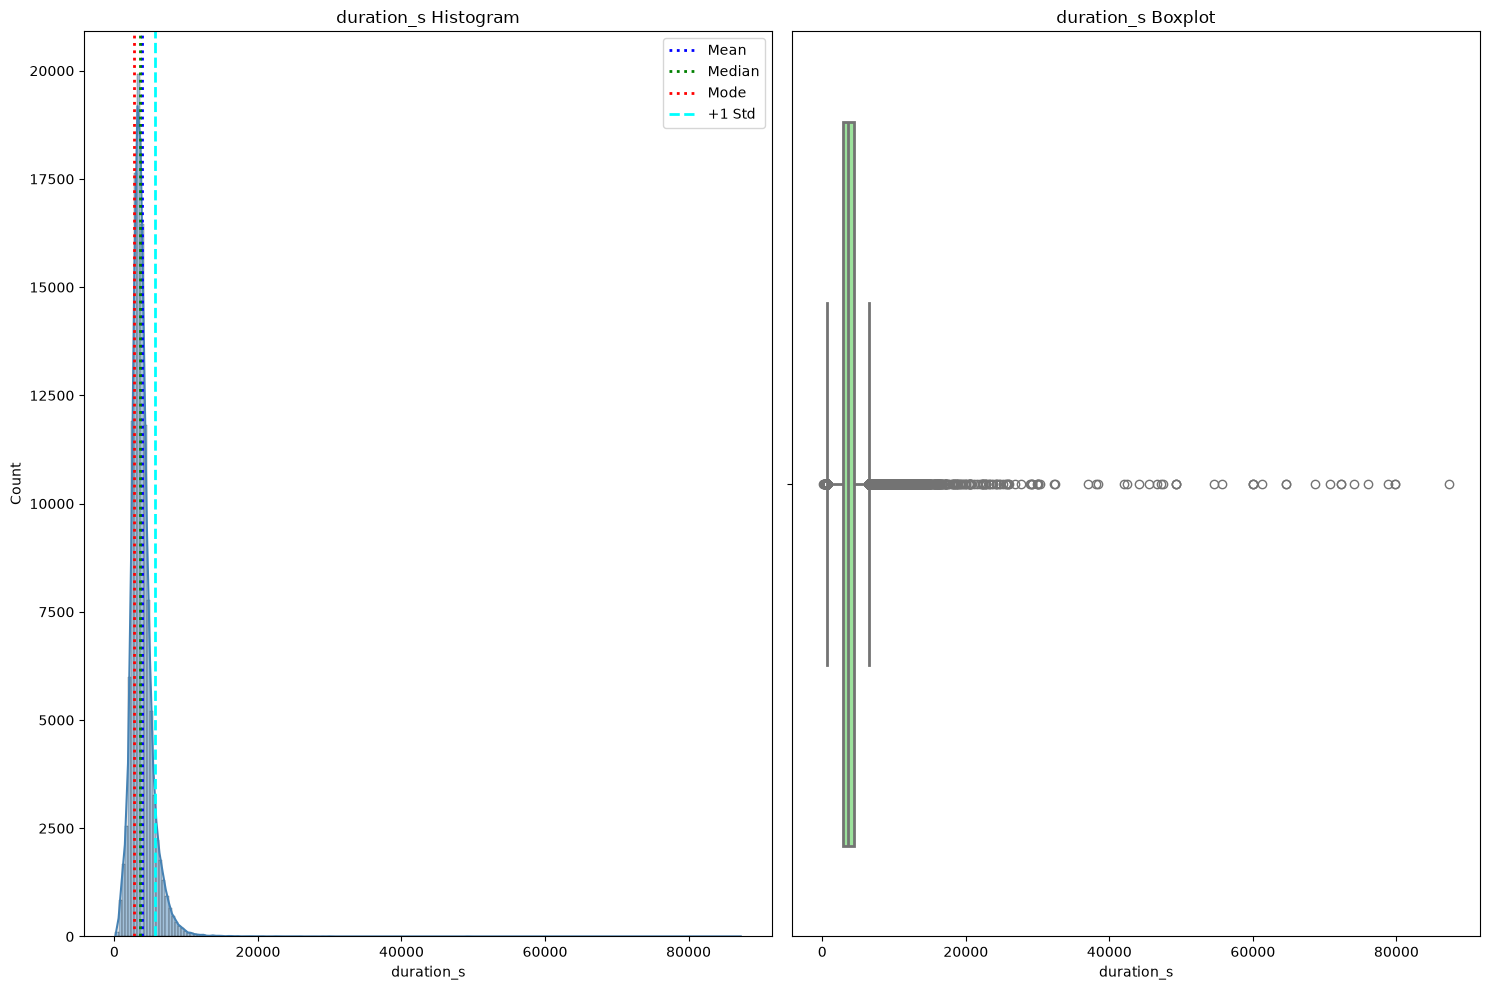

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns
features = dataset.select_dtypes(include=[np.number]).columns

for feature in features:

    fig, axes = plt.subplots(1, 2, figsize=(15, 10))

    # Histogram
    sns.histplot(
        dataset[feature],
        bins=200,
        kde=True,
        color="steelblue",
        ax=axes[0]
    )

    #mean
    axes[0].axvline(
        dataset[feature].mean(),
        color="blue",
        linestyle=":",
        linewidth=2,
        label="Mean"
    )

    #median
    axes[0].axvline(
        dataset[feature].median(),
        color='green',
        linestyle=':',
        linewidth=2,
        label='Median'
    )

    #mode
    axes[0].axvline(
        dataset[feature].mode()[0],
        color='red',
        linestyle=':',
        linewidth=2,
        label='Mode'
        )

    axes[0].axvline(
        dataset[feature].mean() + dataset[feature].std(),
        color="aqua",
        linestyle="--",
        linewidth=2,
        label="+1 Std"
    )

    axes[0].set_title(f"{feature} Histogram")
    axes[0].set_xlabel(feature)
    axes[0].set_ylabel("Count")
    axes[0].legend()

    # Boxplot
    sns.boxplot(
        x=dataset[feature],
        color="lightgreen",
        linewidth=2,
        ax=axes[1]
    )

    axes[1].set_title(f"{feature} Boxplot")
    axes[1].set_xlabel(feature)

    plt.tight_layout()
    plt.show()

In [16]:

import warnings
warnings.filterwarnings('ignore')

droppedFeatures=dataset.select_dtypes(np.object_).columns
targetCol=dataset['track_name']


selectedCols=dataset.drop(columns=droppedFeatures)



# columns=['popularity','liveness','tempo'] #distributions have more than one peak that may cause bias
# selectedCols.drop(inplace=True,columns=columns)

X=selectedCols
Y=targetCol
# print(X)
print(X.explicit.value_counts())
print(X.key.value_counts())
print(X['mode'].value_counts())
print(f"Mean:\t{X.duration_s.mean()},\nMedian:\t{X.duration_s.median()}\n,Mode:\t{X.duration_s.mode()}")


print("target features length:\t",Y.shape[0])
print("selected cols length:\t",X.shape[0])


explicit
0    104252
1      9747
Name: count, dtype: int64
key
7.0     13244
0.0     13061
2.0     11644
9.0     11313
1.0     10772
5.0      9368
11.0     9282
4.0      9008
6.0      7921
10.0     7456
8.0      7360
3.0      3570
Name: count, dtype: int64
mode
1.0    72681
0.0    41318
Name: count, dtype: int64
Mean:	3800.51922312184,
Median:	3548.4333333333334
,Mode:	0    2714.95
Name: duration_s, dtype: float64
target features length:	 113999
selected cols length:	 113999


In [17]:
Y.value_counts().plot.barh()

<Axes: ylabel='track_name'>

Error in callback <function _draw_all_if_interactive at 0x724673197110> (for post_execute), with arguments args (),kwargs {}:


ValueError: 
infinity (888) - feat. Joey Bada$$
                                ^
ParseException: Expected end of text, found '$'  (at char 32), (line:1, col:33)

ValueError: 
infinity (888) - feat. Joey Bada$$
                                ^
ParseException: Expected end of text, found '$'  (at char 32), (line:1, col:33)

<Figure size 640x480 with 1 Axes>

In [18]:
# implementing z score current values
from sklearn.preprocessing import MinMaxScaler #specified range,typically [0,1].
from sklearn.preprocessing import StandardScaler #center the data
from sklearn.preprocessing import RobustScaler 

from sklearn.preprocessing import PowerTransformer


#scaling target feature
# scaler=StandardScaler()
# Y=pd.DataFrame(scaler.fit_transform(Y))

# print(type(Y))

# scaler=RobustScaler()
# selectedCols[['duration_s']]=pd.DataFrame(scaler.fit_transform(selectedCols[['duration_s']]))
# selectedCols['duration_s']


In [19]:
# print(X.isna().any()) #checking NaN values 
#return duration_s
#interpolate current feature
X.duration_s=(X.duration_s.interpolate(method='quadratic')).bfill().ffill()

print(X['duration_s'].isna().sum())
print(X[X['duration_s'].isna()])

#filling remained NaN values in duration_s feature


0
Empty DataFrame
Columns: [popularity, explicit, danceability, energy, key, loudness, mode, speechiness, acousticness, instrumentalness, liveness, valence, tempo, duration_s]
Index: []


In [20]:
n_splits=5
scoring='accuracy'
#model training
def training(model,X,Y,fitting=False):
    from sklearn.model_selection import KFold,cross_val_score

    if fitting:
        from sklearn.model_selection import train_test_split
        X_train,X_test,y_train,y_test=train_test_split(X,Y,test_size=0.3,random_state=42)
        return (model.fit(X_train,y_train),X_test,y_test)
        


In [21]:
#parameter tuning for regression models
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

import warnings 
warnings.filterwarnings('ignore')

import numpy as np


In [22]:
#trying random classifer for current dataset
from sklearn.ensemble import RandomForestClassifier

#defining parameters for RandomForestClassifier
n_estimators=100
estimator_='auto'
max_depth=15
criterion='gini'
random_state=42

randomClassifierModel=RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=5,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42
)
randomClassifierModel

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total n

In [ ]:
# model training and evulation for random forest classifer
model,X_test,y_test=training(randomClassifierModel,X[:9000],Y[:9000],fitting=True)

In [ ]:
result=model.predict(X_test)

# from sklearn.metrics import accuracy_score
# accuracy_score(y_test,result)
from sklearn.metrics import classification_report

classification_report(y_test,result,zero_division=0)

In [ ]:
# from sklearn.metrics import classification_report
# print(classification_report(y_test,result,zero_division=0))